In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

**Install packages**

In [1]:
!pip install -q timm umap-learn thop

**Imports**

In [2]:
import os
import re
import json
import copy
import time
import math
import random
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import umap

try:
    from thop import profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False
    print("thop not installed. GFLOPs will be skipped.")

2026-04-21 13:43:45.123421: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776779025.313495      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776779025.364722      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776779025.842149      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776779025.842220      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776779025.842224      55 computation_placer.cc:177] computation placer alr

**Seed and device**

In [3]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except:
    pass

Device: cuda


**Config**

In [9]:
CONFIG = {
    "img_size_global": 224,
    "img_size_local": 96,
    "num_local_crops": 4,
    "batch_size_ssl": 16,         
    "batch_size_eval": 64,
    "epochs_ssl": 100,
    "epochs_finetune": 25,
    "lr_ssl": 1e-4,
    "lr_finetune": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 2,
    "train_ratio": 0.8,
    "val_ratio_inside_train": 0.1,
    "save_dir": "/kaggle/working/dino_resnet50_outputs",
    "teacher_momentum_base": 0.996,
    "student_temp": 0.1,
    "teacher_temp": 0.04,
    "center_momentum": 0.9,
    "out_dim": 1024,
    "lp_eval_interval": 5,         
    "resume_ssl": False,
    "ssl_checkpoint_path": "/kaggle/working/dino_resnet50_outputs/latest_ssl_checkpoint.pth",
    "ft_patience": 5,
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)

DATA_ROOT = "/kaggle/input/datasets/diptadasopu/processed-rice-varieties/PRBD Microscopic Image of Different Processed Rice"

print("DATA_ROOT exists:", os.path.exists(DATA_ROOT))
if os.path.exists(DATA_ROOT):
    print("Folders inside root:", os.listdir(DATA_ROOT))

DATA_ROOT exists: True
Folders inside root: ['Original_Images', 'Augmented_images']


**Build dataframe**

In [10]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def is_image_file(path):
    return os.path.splitext(path)[1].lower() in VALID_EXTS

def infer_group_id(filepath):
    name = os.path.splitext(os.path.basename(filepath))[0].lower()
    name = re.sub(r'_aug_\d+$', '', name)
    name = re.sub(r'_aug\d+$', '', name)
    name = re.sub(r'_rot_\d+$', '', name)
    name = re.sub(r'_rot\d+$', '', name)
    name = re.sub(r'_rotate_\d+$', '', name)
    name = re.sub(r'_rotate\d+$', '', name)
    name = re.sub(r'_(flip|hflip|vflip|blur|jitter|crop|noise|sharp|contrast|brightness)$', '', name)
    return name

def build_dataframe(data_root):
    rows = []
    target_folders = ["Original_Images", "Augmented_images"]

    for folder_name in target_folders:
        folder_path = os.path.join(data_root, folder_name)
        if not os.path.exists(folder_path):
            print(f"Warning: {folder_path} not found")
            continue

        class_dirs = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        class_dirs = sorted(class_dirs)

        for cls_name in class_dirs:
            cls_dir = os.path.join(folder_path, cls_name)
            for root, _, files in os.walk(cls_dir):
                for f in files:
                    path = os.path.join(root, f)
                    if is_image_file(path):
                        rows.append({
                            "filepath": path,
                            "class_name": cls_name,
                            "source_folder": folder_name,
                            "group_id": infer_group_id(path),
                        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError("No images found. Check DATA_ROOT.")

    classes = sorted(df["class_name"].unique())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    df["label"] = df["class_name"].map(class_to_idx)

    return df, classes, class_to_idx

df, classes, class_to_idx = build_dataframe(DATA_ROOT)

print("Total images:", len(df))
print("Classes:", classes)
print(df.head())
print(df["source_folder"].value_counts())

Total images: 10000
Classes: ['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']
                                            filepath class_name  \
0  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
1  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
2  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
3  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   
4  /kaggle/input/datasets/diptadasopu/processed-r...       Aush   

     source_folder                  group_id  label  
0  Original_Images  processed_s20250325_0155      0  
1  Original_Images  processed_s20250325_0037      0  
2  Original_Images  processed_s20250325_0215      0  
3  Original_Images  processed_s20250325_0099      0  
4  Original_Images  processed_s20250325_0132      0  
source_folder
Augmented_images    8000
Original_Images     2000
Name: count, dtype: int64


**Check grouping**

In [11]:
df.sample(min(20, len(df)), random_state=SEED)[["filepath", "group_id", "class_name", "source_folder"]]

,filepath,group_id,class_name,source_folder
6252,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0017,Ghee Bhog,Augmented_images
4684,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0055,Beroi,Augmented_images
1731,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250423_0003,Miniket,Original_Images
4742,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0006,Beroi,Augmented_images
4521,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0040,Beroi,Augmented_images
6340,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0038,Ghee Bhog,Augmented_images
576,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0141,BR-29,Original_Images
5202,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250423_0132,Chinigura,Augmented_images
6363,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0027,Ghee Bhog,Augmented_images
439,/kaggle/input/datasets/diptadasopu/processed-r...,processed_s20250323_0152,BR-29,Original_Images


**Grouped split**

In [12]:
def grouped_train_test_val_split(df, train_ratio=0.8, val_ratio_inside_train=0.1, random_state=42):
    groups = df["group_id"].values
    y = df["label"].values

    gss = GroupShuffleSplit(n_splits=1, train_size=train_ratio, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, y, groups=groups))

    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

    groups_train = train_df["group_id"].values
    y_train = train_df["label"].values

    train_ratio_inside = 1.0 - val_ratio_inside_train
    gss2 = GroupShuffleSplit(n_splits=1, train_size=train_ratio_inside, random_state=random_state)
    tr_idx, val_idx = next(gss2.split(train_df, y_train, groups=groups_train))

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    val_df = train_df.iloc[val_idx].reset_index(drop=True)

    return tr_df, val_df, test_df

train_df, val_df, test_df = grouped_train_test_val_split(
    df,
    train_ratio=CONFIG["train_ratio"],
    val_ratio_inside_train=CONFIG["val_ratio_inside_train"],
    random_state=SEED,
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))
print("Overlap train-val :", len(set(train_df.group_id) & set(val_df.group_id)))
print("Overlap train-test:", len(set(train_df.group_id) & set(test_df.group_id)))
print("Overlap val-test  :", len(set(val_df.group_id) & set(test_df.group_id)))

Train: 7225
Val  : 790
Test : 1985
Overlap train-val : 0
Overlap train-test: 0
Overlap val-test  : 0


**Save split manifest**

In [13]:
split_manifest = {
    "seed": SEED,
    "train_ratio": CONFIG["train_ratio"],
    "val_ratio_inside_train": CONFIG["val_ratio_inside_train"],
    "train_files": train_df["filepath"].tolist(),
    "val_files": val_df["filepath"].tolist(),
    "test_files": test_df["filepath"].tolist(),
}
with open(os.path.join(CONFIG["save_dir"], "split_manifest.json"), "w") as f:
    json.dump(split_manifest, f)
print("Split manifest saved.")

Split manifest saved.


**DINO transforms**

In [15]:
class DINOTransform:
    def __init__(self, global_size=224, local_size=96, num_local_crops=4):
        self.num_local_crops = num_local_crops

        flip_and_color = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.05),
        ])

        normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.global_transform1 = transforms.Compose([
            transforms.RandomResizedCrop(global_size, scale=(0.5, 1.0)),
            flip_and_color,
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            normalize,
        ])

        self.global_transform2 = transforms.Compose([
            transforms.RandomResizedCrop(global_size, scale=(0.5, 1.0)),
            flip_and_color,
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
            ], p=0.3),
            normalize,
        ])

        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(local_size, scale=(0.2, 0.5)),
            flip_and_color,
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
            ], p=0.5),
            normalize,
        ])

    def __call__(self, image):
        crops = [self.global_transform1(image), self.global_transform2(image)]
        for _ in range(self.num_local_crops):
            crops.append(self.local_transform(image))
        return crops

basic_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size_global"], CONFIG["img_size_global"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

**Datasets and loaders**

In [16]:
class DINODataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        crops = self.transform(img)
        return crops

class LabeledDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        x = self.transform(img)
        y = int(row["label"])
        return x, y

def dino_collate_fn(batch):
    num_crops = len(batch[0])
    crop_batches = []
    for i in range(num_crops):
        crop_batches.append(torch.stack([sample[i] for sample in batch], dim=0))
    return crop_batches

ssl_train_dataset = DINODataset(
    train_df,
    DINOTransform(
        global_size=CONFIG["img_size_global"],
        local_size=CONFIG["img_size_local"],
        num_local_crops=CONFIG["num_local_crops"]
    )
)

probe_train_dataset = LabeledDataset(train_df, basic_transform)
probe_val_dataset   = LabeledDataset(val_df, basic_transform)
probe_test_dataset  = LabeledDataset(test_df, basic_transform)

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=CONFIG["batch_size_ssl"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    drop_last=True,
    collate_fn=dino_collate_fn
)

probe_train_loader = DataLoader(probe_train_dataset, batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
probe_val_loader   = DataLoader(probe_val_dataset,   batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
probe_test_loader  = DataLoader(probe_test_dataset,  batch_size=CONFIG["batch_size_eval"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print("SSL train batches:", len(ssl_train_loader))
print("Probe train size :", len(probe_train_dataset))
print("Probe val size   :", len(probe_val_dataset))
print("Probe test size  :", len(probe_test_dataset))

SSL train batches: 451
Probe train size : 7225
Probe val size   : 790
Probe test size  : 1985


**DINO ResNet50 model**

In [18]:
class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim=1024, hidden_dim=2048, bottleneck_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.Linear(bottleneck_dim, out_dim, bias=False)

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1)
        x = self.last_layer(x)
        return x

class ResNet50Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.embed_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

class DINOStudentTeacher(nn.Module):
    def __init__(self, out_dim=1024):
        super().__init__()
        self.student_backbone = ResNet50Backbone()
        self.teacher_backbone = copy.deepcopy(self.student_backbone)

        self.student_head = DINOHead(self.student_backbone.embed_dim, out_dim=out_dim)
        self.teacher_head = DINOHead(self.student_backbone.embed_dim, out_dim=out_dim)
        self.teacher_head.load_state_dict(self.student_head.state_dict())

        for p in self.teacher_backbone.parameters():
            p.requires_grad = False
        for p in self.teacher_head.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update_teacher(self, m):
        for ps, pt in zip(self.student_backbone.parameters(), self.teacher_backbone.parameters()):
            pt.data = pt.data * m + ps.data * (1.0 - m)

        for ps, pt in zip(self.student_head.parameters(), self.teacher_head.parameters()):
            pt.data = pt.data * m + ps.data * (1.0 - m)

model = DINOStudentTeacher(out_dim=CONFIG["out_dim"]).to(device)
print("Embed dim:", model.student_backbone.embed_dim)

Embed dim: 2048


**DINO loss**

**Optimizer and scheduler**

In [21]:
class DINOLoss(nn.Module):
    def __init__(self, out_dim, teacher_temp=0.04, student_temp=0.1, center_momentum=0.9):
        super().__init__()
        self.teacher_temp = teacher_temp
        self.student_temp = student_temp
        self.center_momentum = center_momentum
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_outputs, teacher_outputs):
        student_out = [s / self.student_temp for s in student_outputs]
        teacher_out = [(t - self.center) / self.teacher_temp for t in teacher_outputs]
        teacher_out = [F.softmax(t, dim=-1).detach() for t in teacher_out]

        total_loss = 0.0
        n_loss_terms = 0

        for iq, q in enumerate(teacher_out):
            for iv, v in enumerate(student_out):
                if iv == iq:
                    continue
                loss = torch.sum(-q * F.log_softmax(v, dim=-1), dim=-1).mean()
                total_loss += loss
                n_loss_terms += 1

        total_loss /= n_loss_terms

        batch_center = torch.cat(teacher_outputs, dim=0).mean(dim=0, keepdim=True)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)

        return total_loss

dino_loss = DINOLoss(
    out_dim=CONFIG["out_dim"],
    teacher_temp=CONFIG["teacher_temp"],
    student_temp=CONFIG["student_temp"],
    center_momentum=CONFIG["center_momentum"]
).to(device)

**Helper functions**

In [23]:
optimizer = torch.optim.AdamW(
    list(model.student_backbone.parameters()) + list(model.student_head.parameters()),
    lr=CONFIG["lr_ssl"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs_ssl"])
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

**Resume setup**

In [32]:
def get_rng_states():
    state = {
        "python_random": random.getstate(),
        "numpy_random": np.random.get_state(),
        "torch_random": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["torch_cuda_random"] = torch.cuda.get_rng_state_all()
    return state

def set_rng_states(state):
    random.setstate(state["python_random"])
    np.random.set_state(state["numpy_random"])
    torch.set_rng_state(state["torch_random"])
    if torch.cuda.is_available() and "torch_cuda_random" in state:
        torch.cuda.set_rng_state_all(state["torch_cuda_random"])

def save_ssl_checkpoint(path, model, optimizer, scheduler, epoch, global_step, best_metric, history, lp_val_acc=None):
    ckpt = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
        "best_metric": best_metric,
        "lp_val_acc": lp_val_acc,
        "rng_states": get_rng_states(),
        "history": history,
        "config": CONFIG,
        "classes": classes,
    }
    torch.save(ckpt, path)

def load_ssl_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    set_rng_states(ckpt["rng_states"])
    return ckpt

@torch.no_grad()
def extract_features(dataloader, encoder):
    encoder.eval()
    all_feats, all_labels = [], []
    for x, y in dataloader:
        x = x.to(device, non_blocking=True)
        feats = encoder(x)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(y.numpy())
    feats = np.concatenate(all_feats, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return feats, labels

def linear_probe_val_accuracy(encoder, train_loader, val_loader):
    X_train_lp, y_train_lp = extract_features(train_loader, encoder)
    X_val_lp, y_val_lp = extract_features(val_loader, encoder)

    clf = LogisticRegression(
        max_iter=1500,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=SEED,
        n_jobs=-1
    )
    clf.fit(X_train_lp, y_train_lp)
    pred_val = clf.predict(X_val_lp)
    return accuracy_score(y_val_lp, pred_val)

**SSL training loop**

In [27]:
start_epoch = 1
global_step = 0
best_ssl_loss = float("inf")
best_lp_val_acc = -1
history_ssl = {"epoch": [], "loss": [], "time_sec": [], "lp_val_acc": []}

if CONFIG["resume_ssl"] and os.path.exists(CONFIG["ssl_checkpoint_path"]):
    ckpt = load_ssl_checkpoint(CONFIG["ssl_checkpoint_path"], model, optimizer, scheduler)
    start_epoch = ckpt["epoch"] + 1
    global_step = ckpt["global_step"]
    best_ssl_loss = ckpt["best_metric"]
    best_lp_val_acc = ckpt.get("lp_val_acc", -1)
    history_ssl = ckpt["history"]
    print("Resumed from:", CONFIG["ssl_checkpoint_path"])
    print("Starting from epoch:", start_epoch)
else:
    print("Starting fresh SSL training")

Starting fresh SSL training


**SSL training loop**

In [28]:
print("Starting DINO pretraining...")

for epoch in range(start_epoch, CONFIG["epochs_ssl"] + 1):
    model.train()
    running_loss = 0.0
    start_time = time.time()

    m = 1 - (1 - CONFIG["teacher_momentum_base"]) * (np.cos(np.pi * epoch / CONFIG["epochs_ssl"]) + 1) / 2

    for crops in ssl_train_loader:
        crops = [crop.to(device, non_blocking=True) for crop in crops]

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            teacher_outputs = []
            for crop in crops[:2]:
                feat = model.teacher_backbone(crop)
                out = model.teacher_head(feat)
                teacher_outputs.append(out)

            student_outputs = []
            for crop in crops:
                feat = model.student_backbone(crop)
                out = model.student_head(feat)
                student_outputs.append(out)

            loss = dino_loss(student_outputs, teacher_outputs)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        model.update_teacher(m)

        running_loss += loss.item()
        global_step += 1

    scheduler.step()

    epoch_loss = running_loss / len(ssl_train_loader)
    epoch_time = time.time() - start_time

    current_lp_val_acc = None
    if (epoch % CONFIG["lp_eval_interval"] == 0) or (epoch == CONFIG["epochs_ssl"]):
        encoder_for_eval = model.student_backbone.to(device)
        current_lp_val_acc = linear_probe_val_accuracy(encoder_for_eval, probe_train_loader, probe_val_loader)
        print(f"Linear-probe Val Accuracy @ epoch {epoch}: {current_lp_val_acc:.4f}")

        if current_lp_val_acc > best_lp_val_acc:
            best_lp_val_acc = current_lp_val_acc
            save_ssl_checkpoint(
                os.path.join(CONFIG["save_dir"], "best_ssl_checkpoint.pth"),
                model, optimizer, scheduler, epoch, global_step, best_ssl_loss, history_ssl, best_lp_val_acc
            )
            torch.save(model.student_backbone.state_dict(), os.path.join(CONFIG["save_dir"], "best_frozen_encoder.pth"))

    history_ssl["epoch"].append(epoch)
    history_ssl["loss"].append(epoch_loss)
    history_ssl["time_sec"].append(epoch_time)
    history_ssl["lp_val_acc"].append(current_lp_val_acc)

    save_ssl_checkpoint(
        os.path.join(CONFIG["save_dir"], "latest_ssl_checkpoint.pth"),
        model, optimizer, scheduler, epoch, global_step, best_ssl_loss, history_ssl, current_lp_val_acc
    )

    if epoch_loss < best_ssl_loss:
        best_ssl_loss = epoch_loss

    print(f"Epoch [{epoch:03d}/{CONFIG['epochs_ssl']}] Loss: {epoch_loss:.4f} | EMA m: {m:.6f} | Time: {epoch_time:.2f}s")

Starting DINO pretraining...
Epoch [001/100] Loss: 6.3293 | EMA m: 0.996001 | Time: 160.36s
Epoch [002/100] Loss: 2.5692 | EMA m: 0.996004 | Time: 145.82s
Epoch [003/100] Loss: 0.8482 | EMA m: 0.996009 | Time: 145.64s
Epoch [004/100] Loss: 0.5880 | EMA m: 0.996016 | Time: 146.62s
Linear-probe Val Accuracy @ epoch 5: 0.9481
Epoch [005/100] Loss: 0.5170 | EMA m: 0.996025 | Time: 148.41s
Epoch [006/100] Loss: 0.4726 | EMA m: 0.996035 | Time: 145.16s
Epoch [007/100] Loss: 0.4469 | EMA m: 0.996048 | Time: 148.36s
Epoch [008/100] Loss: 0.4218 | EMA m: 0.996063 | Time: 148.73s
Epoch [009/100] Loss: 0.3980 | EMA m: 0.996079 | Time: 148.54s
Linear-probe Val Accuracy @ epoch 10: 0.9620
Epoch [010/100] Loss: 0.3942 | EMA m: 0.996098 | Time: 147.24s
Epoch [011/100] Loss: 0.3794 | EMA m: 0.996118 | Time: 144.03s
Epoch [012/100] Loss: 0.3591 | EMA m: 0.996140 | Time: 145.82s
Epoch [013/100] Loss: 0.3464 | EMA m: 0.996164 | Time: 145.60s
Epoch [014/100] Loss: 0.3370 | EMA m: 0.996190 | Time: 145.91s


**SSL curves and logs**

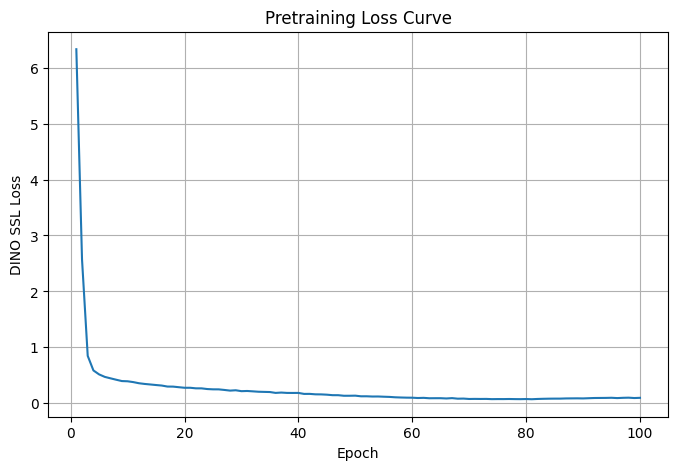

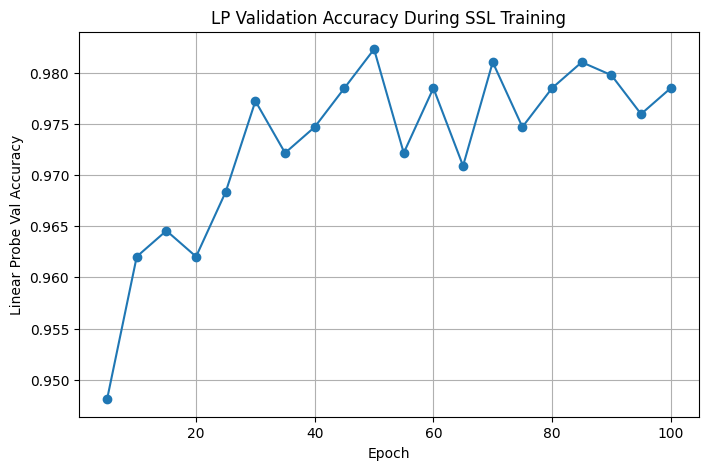

In [29]:
history_df = pd.DataFrame(history_ssl)
history_df.to_csv(os.path.join(CONFIG["save_dir"], "ssl_history.csv"), index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["loss"])
plt.xlabel("Epoch")
plt.ylabel("DINO SSL Loss")
plt.title("Pretraining Loss Curve")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
tmp = history_df.dropna(subset=["lp_val_acc"])
if len(tmp) > 0:
    plt.plot(tmp["epoch"], tmp["lp_val_acc"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Linear Probe Val Accuracy")
    plt.title("LP Validation Accuracy During SSL Training")
    plt.grid(True)
    plt.show()
else:
    print("No linear-probe validation points logged yet.")

**Load best encoder**

In [31]:
best_ckpt = torch.load(
    os.path.join(CONFIG["save_dir"], "best_ssl_checkpoint.pth"),
    map_location=device,
    weights_only=False
)

model.load_state_dict(best_ckpt["model_state"])
encoder = model.student_backbone.to(device)
encoder.eval()
print("Best encoder loaded")
print("Best LP val acc:", best_ckpt.get("lp_val_acc", None))

Best encoder loaded
Best LP val acc: 0.9822784810126582


**Extract frozen features**

In [33]:
X_train, y_train = extract_features(probe_train_loader, encoder)
X_val, y_val     = extract_features(probe_val_loader, encoder)
X_test, y_test   = extract_features(probe_test_loader, encoder)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (7225, 2048)
X_val  : (790, 2048)
X_test : (1985, 2048)


**Linear probe on test**

In [34]:
lp_start = time.time()
linear_probe = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs",
    random_state=SEED,
    n_jobs=-1
)
linear_probe.fit(X_train, y_train)
lp_train_time = time.time() - lp_start

lp_test_start = time.time()
lp_pred = linear_probe.predict(X_test)
lp_prob = linear_probe.predict_proba(X_test)
lp_test_time = time.time() - lp_test_start

lp_acc = accuracy_score(y_test, lp_pred)
lp_prec, lp_rec, lp_f1, _ = precision_recall_fscore_support(y_test, lp_pred, average="weighted", zero_division=0)
y_test_bin = label_binarize(y_test, classes=list(range(len(classes))))
lp_auc = roc_auc_score(y_test_bin, lp_prob, multi_class="ovr", average="weighted")

print("Linear Probe Accuracy :", round(lp_acc, 4))
print("Linear Probe Precision:", round(lp_prec, 4))
print("Linear Probe Recall   :", round(lp_rec, 4))
print("Linear Probe F1       :", round(lp_f1, 4))
print("Linear Probe ROC-AUC  :", round(lp_auc, 4))
print("LP Train time         :", round(lp_train_time, 2), "sec")
print("LP Test time          :", round(lp_test_time, 2), "sec")

Linear Probe Accuracy : 0.9703
Linear Probe Precision: 0.9703
Linear Probe Recall   : 0.9703
Linear Probe F1       : 0.9702
Linear Probe ROC-AUC  : 0.9991
LP Train time         : 6.73 sec
LP Test time          : 0.03 sec


**Shallow heads**

In [35]:
results_shallow = []

models_shallow = {
    "MLP": MLPClassifier(hidden_layer_sizes=(256,), max_iter=300, random_state=SEED),
    "SVM": SVC(probability=True, random_state=SEED),
    "DecisionTree": DecisionTreeClassifier(random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

for name, clf in models_shallow.items():
    print(f"\nTraining {name}...")
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    t1 = time.time()
    pred = clf.predict(X_test)
    test_time = time.time() - t1

    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted", zero_division=0)

    if hasattr(clf, "predict_proba"):
        prob = clf.predict_proba(X_test)
        auc = roc_auc_score(y_test_bin, prob, multi_class="ovr", average="weighted")
    else:
        auc = np.nan

    results_shallow.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
        "train_time_sec": train_time,
        "test_time_sec": test_time,
    })

shallow_df = pd.DataFrame(results_shallow)
shallow_df


Training MLP...

Training SVM...

Training DecisionTree...

Training RandomForest...


,model,accuracy,precision,recall,f1,roc_auc,train_time_sec,test_time_sec
0,MLP,0.972796,0.972789,0.972796,0.972711,0.999050,14.696416,0.014818
1,SVM,0.967758,0.968123,0.967758,0.967588,0.998776,49.337415,10.133338
2,DecisionTree,0.834257,0.841667,0.834257,0.835648,0.908256,13.382441,0.002326
3,RandomForest,0.952141,0.953585,0.952141,0.952152,0.997260,14.216546,0.078339


**Classification report and per-class accuracy**

In [36]:
print(classification_report(y_test, lp_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_test, lp_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "class": classes,
    "per_class_accuracy": per_class_acc
})
per_class_df

               precision    recall  f1-score   support

         Aush     1.0000    1.0000    1.0000       180
        BR-28     0.9104    0.9150    0.9127       200
        BR-29     0.9569    1.0000    0.9780       200
        Beroi     1.0000    1.0000    1.0000       195
    Chinigura     1.0000    1.0000    1.0000       210
    Ghee Bhog     0.9730    0.9231    0.9474       195
 Katari Najir     0.9458    0.9515    0.9486       165
Katari Siddho     0.9255    0.9158    0.9206       190
      Miniket     1.0000    1.0000    1.0000       220
       Swarna     0.9827    0.9870    0.9848       230

     accuracy                         0.9703      1985
    macro avg     0.9694    0.9692    0.9692      1985
 weighted avg     0.9703    0.9703    0.9702      1985



,class,per_class_accuracy
0,Aush,1.000000
1,BR-28,0.915000
2,BR-29,1.000000
3,Beroi,1.000000
4,Chinigura,1.000000
5,Ghee Bhog,0.923077
6,Katari Najir,0.951515
7,Katari Siddho,0.915789
8,Miniket,1.000000
9,Swarna,0.986957


**Confusion matrix and ROC**

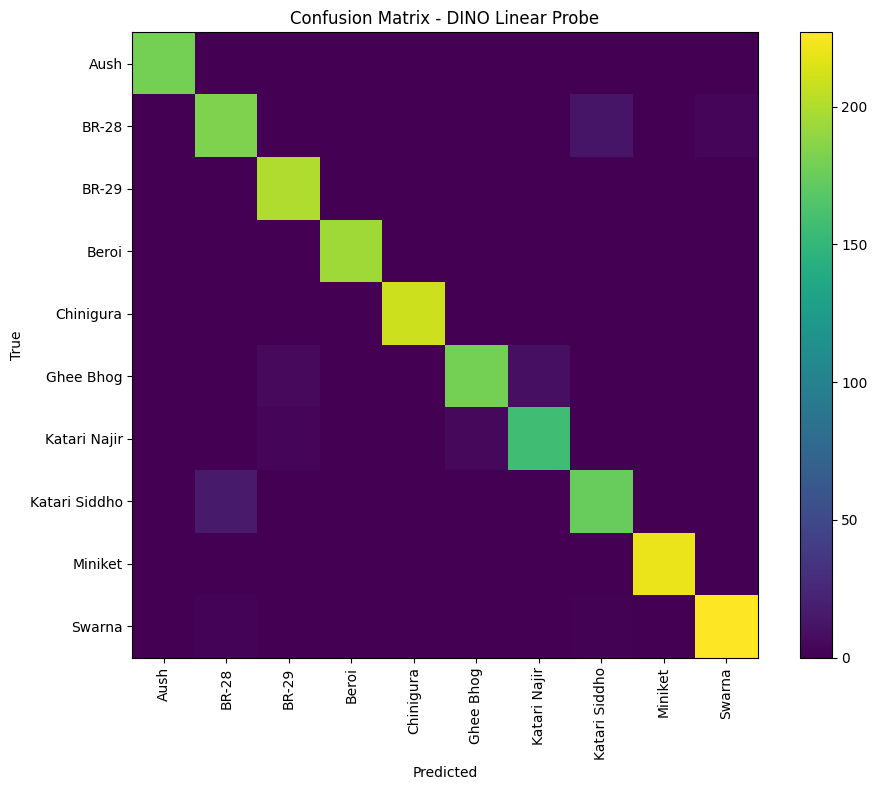

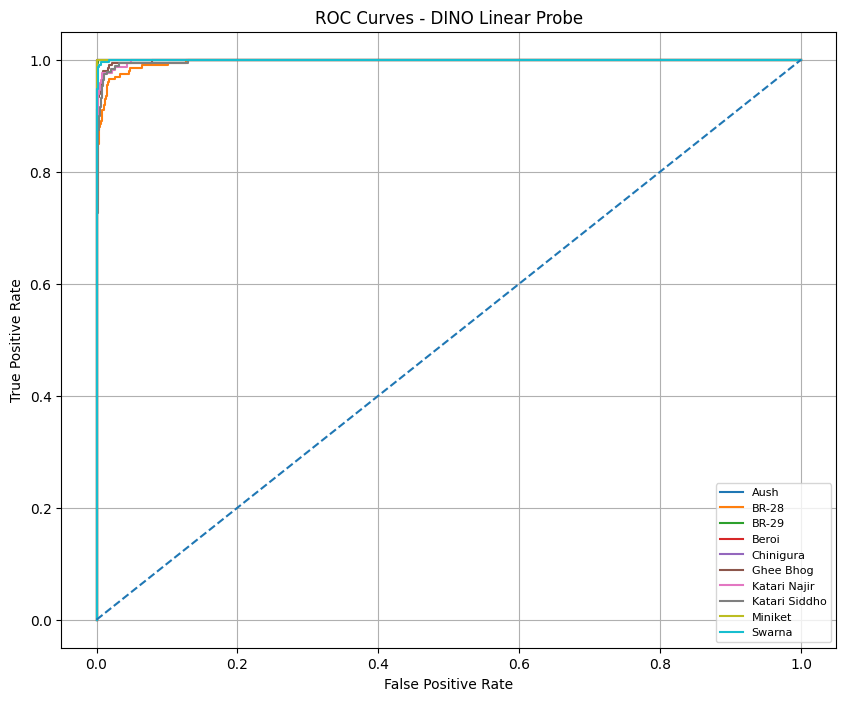

In [37]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - DINO Linear Probe")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for i, cls_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], lp_prob[:, i])
    plt.plot(fpr, tpr, label=cls_name)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - DINO Linear Probe")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

**k-NN**

In [38]:
knn_results = []
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_knn = knn.predict(X_test)
    acc_knn = accuracy_score(y_test, pred_knn)
    knn_results.append({"k": k, "accuracy": acc_knn})
    print(f"k={k} -> Accuracy: {acc_knn:.4f}")

knn_df = pd.DataFrame(knn_results)
knn_df

k=1 -> Accuracy: 0.9194
k=5 -> Accuracy: 0.9406
k=20 -> Accuracy: 0.9355


,k,accuracy
0,1,0.919395
1,5,0.940554
2,20,0.935516


**PCA / t-SNE / UMAP**

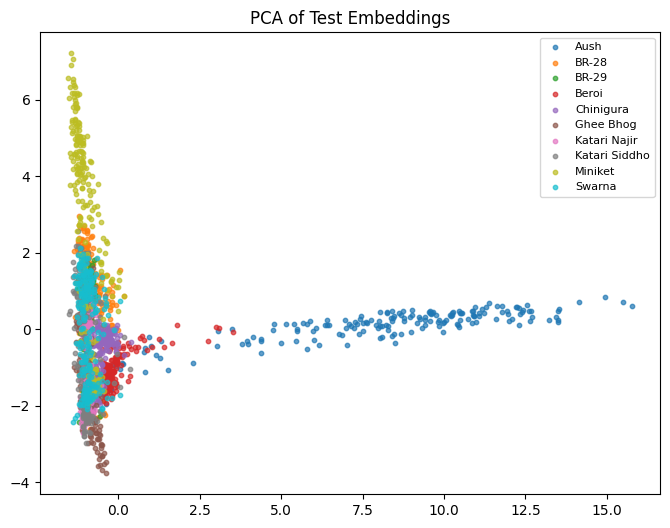

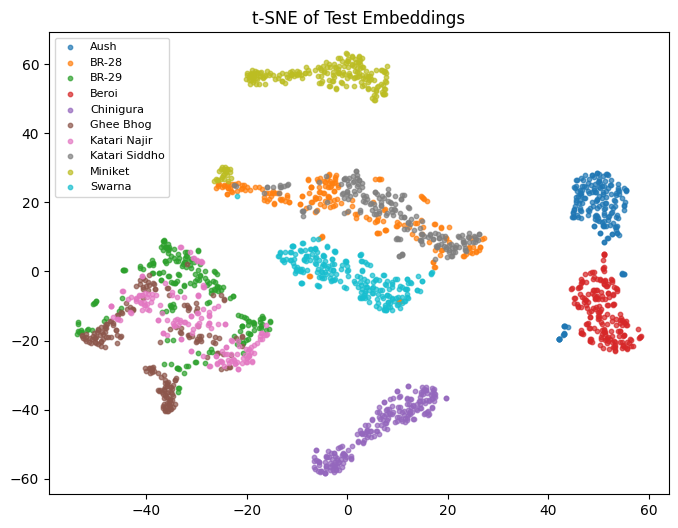

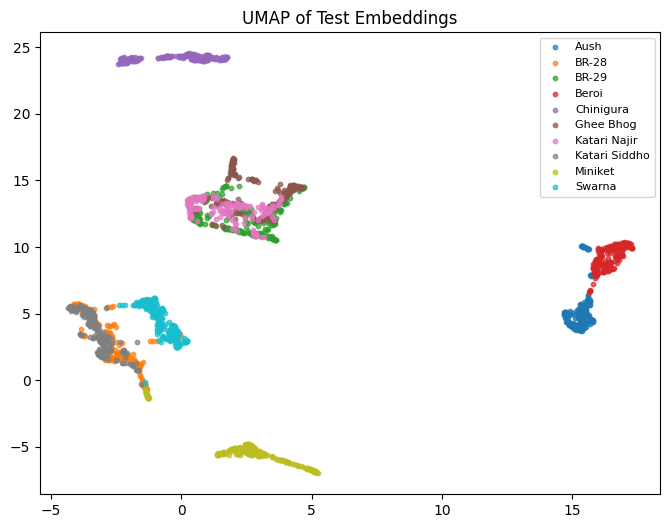

In [39]:
max_vis = 2000

if len(X_test) > max_vis:
    idx = np.random.choice(len(X_test), max_vis, replace=False)
    X_vis = X_test[idx]
    y_vis = y_test[idx]
else:
    X_vis = X_test
    y_vis = y_test

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(pca_2d[m, 0], pca_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("PCA of Test Embeddings")
plt.legend(fontsize=8)
plt.show()

tsne_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(tsne_2d[m, 0], tsne_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("t-SNE of Test Embeddings")
plt.legend(fontsize=8)
plt.show()

umap_2d = umap.UMAP(n_components=2, random_state=SEED).fit_transform(X_vis)
plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    m = (y_vis == i)
    plt.scatter(umap_2d[m, 0], umap_2d[m, 1], s=10, alpha=0.7, label=cls)
plt.title("UMAP of Test Embeddings")
plt.legend(fontsize=8)
plt.show()

**Silhouette score**

In [40]:
sil_score = silhouette_score(X_vis, y_vis)
print("Silhouette Score:", round(sil_score, 4))

Silhouette Score: 0.1226


**Label efficiency**

In [41]:
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]
label_eff_results = []

for frac in fractions:
    sampled_idx = []

    for c in np.unique(y_train):
        c_idx = np.where(y_train == c)[0]
        n_take = max(1, int(len(c_idx) * frac))
        chosen = np.random.choice(c_idx, n_take, replace=False)
        sampled_idx.extend(chosen.tolist())

    sampled_idx = np.array(sampled_idx)

    clf_frac = LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=SEED,
        n_jobs=-1
    )
    clf_frac.fit(X_train[sampled_idx], y_train[sampled_idx])
    pred_frac = clf_frac.predict(X_test)
    acc_frac = accuracy_score(y_test, pred_frac)

    label_eff_results.append({
        "fraction": frac,
        "accuracy": acc_frac,
        "n_samples": len(sampled_idx)
    })

    print(f"{int(frac*100)}% labels -> Accuracy: {acc_frac:.4f}")

label_eff_df = pd.DataFrame(label_eff_results)
label_eff_df

1% labels -> Accuracy: 0.8166
5% labels -> Accuracy: 0.9370
10% labels -> Accuracy: 0.9587
25% labels -> Accuracy: 0.9698
50% labels -> Accuracy: 0.9678


,fraction,accuracy,n_samples
0,0.01,0.816625,67
1,0.05,0.937028,357
2,0.10,0.958690,721
3,0.25,0.969773,1802
4,0.50,0.967758,3611


**Plot label efficiency**

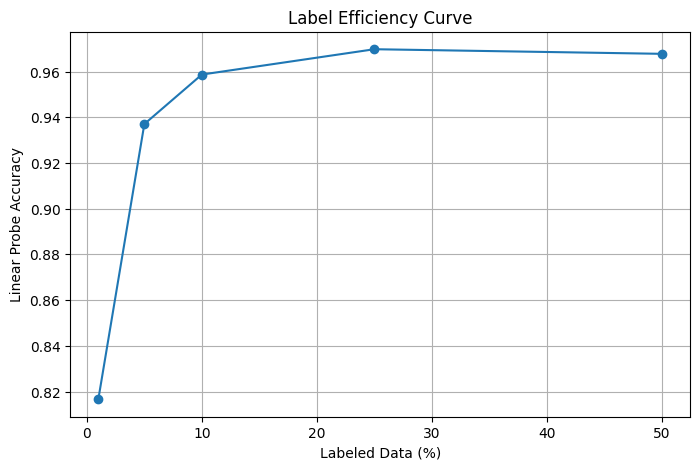

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(label_eff_df["fraction"] * 100, label_eff_df["accuracy"], marker="o")
plt.xlabel("Labeled Data (%)")
plt.ylabel("Linear Probe Accuracy")
plt.title("Label Efficiency Curve")
plt.grid(True)
plt.show()

**Fine-tuning loaders**

In [47]:
ft_train_loader = DataLoader(
    LabeledDataset(train_df, basic_transform),
    batch_size=CONFIG["batch_size_eval"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

ft_val_loader = DataLoader(
    LabeledDataset(val_df, basic_transform),
    batch_size=CONFIG["batch_size_eval"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

ft_test_loader = DataLoader(
    LabeledDataset(test_df, basic_transform),
    batch_size=CONFIG["batch_size_eval"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

**Fine-tuning model**

In [48]:
class FineTuneModel(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(backbone.embed_dim, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        out = self.fc(feat)
        return out

ft_backbone = copy.deepcopy(encoder)
ft_model = FineTuneModel(ft_backbone, len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
ft_optimizer = torch.optim.AdamW(ft_model.parameters(), lr=CONFIG["lr_finetune"], weight_decay=CONFIG["weight_decay"])
ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ft_optimizer, T_max=CONFIG["epochs_finetune"])

**Fine-tuning helpers**

In [49]:
def evaluate_ft(model, loader):
    model.eval()
    all_preds, all_probs, all_targets = [], [], []
    loss_sum = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            loss_sum += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    avg_loss = loss_sum / len(loader)
    return avg_loss, np.array(all_targets), np.array(all_preds), np.array(all_probs)

**Fine-tuning loop**

In [50]:
best_val_acc = -1
patience_counter = 0
ft_history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": []}

ft_start = time.time()

for epoch in range(1, CONFIG["epochs_finetune"] + 1):
    ft_model.train()
    train_loss_sum = 0.0

    for x, y in ft_train_loader:
        x = x.to(device)
        y = y.to(device)

        ft_optimizer.zero_grad()
        logits = ft_model(x)
        loss = criterion(logits, y)
        loss.backward()
        ft_optimizer.step()

        train_loss_sum += loss.item()

    ft_scheduler.step()

    train_loss = train_loss_sum / len(ft_train_loader)
    val_loss, val_targets, val_preds, val_probs = evaluate_ft(ft_model, ft_val_loader)
    val_acc = accuracy_score(val_targets, val_preds)

    ft_history["epoch"].append(epoch)
    ft_history["train_loss"].append(train_loss)
    ft_history["val_loss"].append(val_loss)
    ft_history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(ft_model.state_dict(), os.path.join(CONFIG["save_dir"], "best_finetune_model.pth"))
    else:
        patience_counter += 1

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if patience_counter >= CONFIG["ft_patience"]:
        print("Early stopping triggered")
        break

ft_train_total_time = time.time() - ft_start

Epoch 01 | train_loss=0.5060 | val_loss=0.0979 | val_acc=0.9595
Epoch 02 | train_loss=0.0504 | val_loss=0.1199 | val_acc=0.9570
Epoch 03 | train_loss=0.0229 | val_loss=0.0624 | val_acc=0.9747
Epoch 04 | train_loss=0.0173 | val_loss=0.0815 | val_acc=0.9734
Epoch 05 | train_loss=0.0090 | val_loss=0.1120 | val_acc=0.9684
Epoch 06 | train_loss=0.0056 | val_loss=0.0544 | val_acc=0.9759
Epoch 07 | train_loss=0.0057 | val_loss=0.0449 | val_acc=0.9823
Epoch 08 | train_loss=0.0124 | val_loss=0.0965 | val_acc=0.9696
Epoch 09 | train_loss=0.0042 | val_loss=0.0459 | val_acc=0.9823
Epoch 10 | train_loss=0.0112 | val_loss=0.0694 | val_acc=0.9747
Epoch 11 | train_loss=0.0052 | val_loss=0.0296 | val_acc=0.9861
Epoch 12 | train_loss=0.0015 | val_loss=0.0446 | val_acc=0.9835
Epoch 13 | train_loss=0.0012 | val_loss=0.0280 | val_acc=0.9861
Epoch 14 | train_loss=0.0025 | val_loss=0.0406 | val_acc=0.9823
Epoch 15 | train_loss=0.0006 | val_loss=0.0352 | val_acc=0.9848
Epoch 16 | train_loss=0.0003 | val_loss=

**Fine-tuning curves**

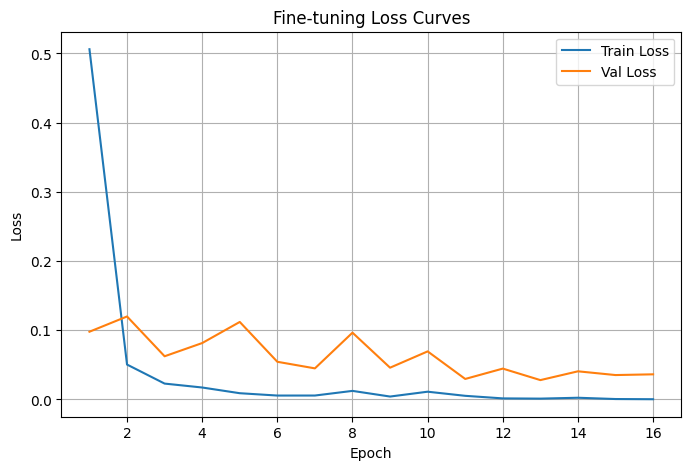

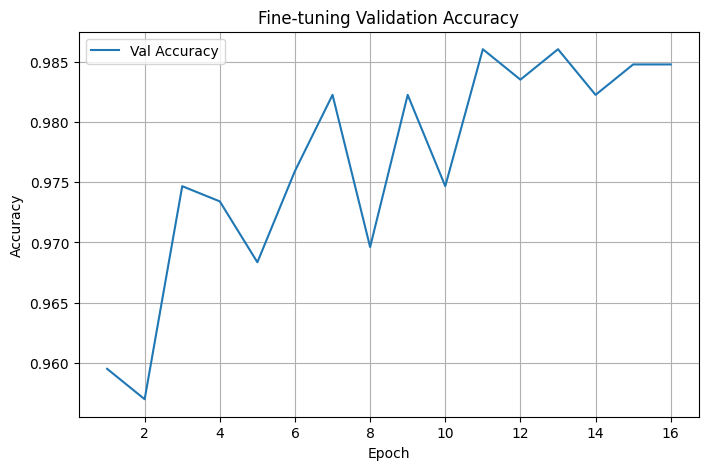

In [51]:
ft_history_df = pd.DataFrame(ft_history)
ft_history_df.to_csv(os.path.join(CONFIG["save_dir"], "finetune_history.csv"), index=False)

plt.figure(figsize=(8, 5))
plt.plot(ft_history_df["epoch"], ft_history_df["train_loss"], label="Train Loss")
plt.plot(ft_history_df["epoch"], ft_history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-tuning Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(ft_history_df["epoch"], ft_history_df["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-tuning Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Fine-tuning test metrics**

In [52]:
ft_model.load_state_dict(torch.load(os.path.join(CONFIG["save_dir"], "best_finetune_model.pth"), map_location=device))

ft_test_start = time.time()
ft_test_loss, ft_targets, ft_preds, ft_probs = evaluate_ft(ft_model, ft_test_loader)
ft_test_time = time.time() - ft_test_start

ft_acc = accuracy_score(ft_targets, ft_preds)
ft_prec, ft_rec, ft_f1, _ = precision_recall_fscore_support(ft_targets, ft_preds, average="weighted", zero_division=0)
ft_auc = roc_auc_score(label_binarize(ft_targets, classes=list(range(len(classes)))), ft_probs, multi_class="ovr", average="weighted")

print("Fine-tune Accuracy  :", round(ft_acc, 4))
print("Fine-tune Precision :", round(ft_prec, 4))
print("Fine-tune Recall    :", round(ft_rec, 4))
print("Fine-tune F1        :", round(ft_f1, 4))
print("Fine-tune ROC-AUC   :", round(ft_auc, 4))
print("Fine-tune Train time:", round(ft_train_total_time, 2), "sec")
print("Fine-tune Test time :", round(ft_test_time, 2), "sec")

Fine-tune Accuracy  : 0.9839
Fine-tune Precision : 0.984
Fine-tune Recall    : 0.9839
Fine-tune F1        : 0.9838
Fine-tune ROC-AUC   : 0.9996
Fine-tune Train time: 1253.58 sec
Fine-tune Test time : 9.68 sec


**GFLOPs**

In [53]:
if HAS_THOP:
    dummy = torch.randn(1, 3, CONFIG["img_size_global"], CONFIG["img_size_global"]).to(device)
    macs, params = profile(encoder, inputs=(dummy,), verbose=False)
    gflops = (2 * macs) / 1e9
    print(f"GFLOPs per inference @ {CONFIG['img_size_global']}x{CONFIG['img_size_global']}: {gflops:.4f}")
    print(f"Params: {params/1e6:.2f}M")
else:
    gflops = None
    print("GFLOPs skipped.")

GFLOPs per inference @ 224x224: 8.2634
Params: 23.51M


**Environment info**

In [54]:
env_info = {
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
}
env_info_df = pd.DataFrame([env_info])
env_info_df.to_csv(os.path.join(CONFIG["save_dir"], "environment_info.csv"), index=False)
env_info_df

,python_version,torch_version,cuda_available,cuda_version,device_name
0,3.12.12,2.10.0+cu128,True,12.8,Tesla T4


**Save final summary**

In [55]:
summary = {
    "method": "DINO",
    "backbone": "ResNet50",
    "split": f"{int(CONFIG['train_ratio']*100)}:{int((1-CONFIG['train_ratio'])*100)}",
    "epochs_ssl": CONFIG["epochs_ssl"],
    "epochs_finetune": CONFIG["epochs_finetune"],
    "img_size": CONFIG["img_size_global"],
    "best_lp_val_acc_during_ssl": best_lp_val_acc,
    "linear_probe_accuracy": lp_acc,
    "linear_probe_precision": lp_prec,
    "linear_probe_recall": lp_rec,
    "linear_probe_f1": lp_f1,
    "linear_probe_auc": lp_auc,
    "linear_probe_train_time_sec": lp_train_time,
    "linear_probe_test_time_sec": lp_test_time,
    "fine_tune_accuracy": ft_acc,
    "fine_tune_precision": ft_prec,
    "fine_tune_recall": ft_rec,
    "fine_tune_f1": ft_f1,
    "fine_tune_auc": ft_auc,
    "fine_tune_train_time_sec": ft_train_total_time,
    "fine_tune_test_time_sec": ft_test_time,
    "silhouette_score": sil_score,
    "gflops": gflops,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(CONFIG["save_dir"], "final_summary.csv"), index=False)
per_class_df.to_csv(os.path.join(CONFIG["save_dir"], "per_class_accuracy.csv"), index=False)
shallow_df.to_csv(os.path.join(CONFIG["save_dir"], "shallow_heads_results.csv"), index=False)
label_eff_df.to_csv(os.path.join(CONFIG["save_dir"], "label_efficiency.csv"), index=False)
knn_df.to_csv(os.path.join(CONFIG["save_dir"], "knn_results.csv"), index=False)

print("Saved everything in:", CONFIG["save_dir"])
summary_df

Saved everything in: /kaggle/working/dino_resnet50_outputs


,method,backbone,split,epochs_ssl,epochs_finetune,img_size,best_lp_val_acc_during_ssl,linear_probe_accuracy,linear_probe_precision,linear_probe_recall,...,linear_probe_test_time_sec,fine_tune_accuracy,fine_tune_precision,fine_tune_recall,fine_tune_f1,fine_tune_auc,fine_tune_train_time_sec,fine_tune_test_time_sec,silhouette_score,gflops
0,DINO,ResNet50,80:19,100,25,224,0.982278,0.970277,0.970342,0.970277,...,0.034656,0.983879,0.984027,0.983879,0.983844,0.999626,1253.580941,9.67827,0.122621,8.263389
